# Сравнение Классификаторов на MNIST (рукописные цифры)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
from tensorflow.keras.datasets import mnist
warnings.filterwarnings("ignore")

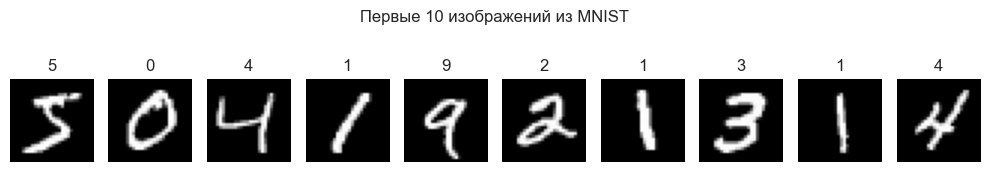

In [14]:
# Загружаем и ограничиваем размер
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()
X_train = X_train_full[:10000].reshape(-1, 28 * 28)
y_train = y_train_full[:10000]
X_test = X_test_full[:2000].reshape(-1, 28 * 28)
y_test = y_test_full[:2000]

# Преобразуем данные
X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Визуализация первых 10 изображений
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
plt.suptitle("Первые 10 изображений из MNIST")
plt.tight_layout()
plt.show()



In [15]:
# Классификаторы
models = {
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "QDA": QuadraticDiscriminantAnalysis(),
    "LightGBM": LGBMClassifier(random_state=42),
    "K Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "Dummy": DummyClassifier(strategy='most_frequent'),
    "SVM (Linear)": SVC(kernel='linear', probability=True, random_state=42)
}

Training: Gradient Boosting
Training: CatBoost
Training: AdaBoost
Training: Extra Trees
Training: QDA
Training: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024829 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 89759
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 560
[LightGBM] [Info] Start training from score -2.301586
[LightGBM] [Info] Start training from score -2.183026
[LightGBM] [Info] Start training from score -2.311626
[LightGBM] [Info] Start training from score -2.271086
[LightGBM] [Info] Start training from score -2.322788
[LightGBM] [Info] Start training from score -2.449926
[LightGBM] [Info] Start training from score -2.288682
[LightGBM] [Info] Start training from score -2.234926
[LightGBM] [Info] Start training from score -2.360214
[LightGBM] [Info] Start training from score -2.324831
[LightGBM] [Warning] No further splits with posi

,Model,Accuracy,F1 Score,ROC AUC
5,LightGBM,0.9435,0.943350,0.997043
1,CatBoost,0.9435,0.942882,0.997371
8,XGBoost,0.9390,0.938745,0.996926
3,Extra Trees,0.9370,0.936292,0.996147
0,Gradient Boosting,0.8945,0.893221,0.993359
6,K Neighbors,0.8865,0.885809,0.976061
10,SVM (Linear),0.8870,0.885157,0.991437
7,Decision Tree,0.7810,0.778126,0.876982
4,QDA,0.6370,0.618233,0.877041
2,AdaBoost,0.6260,0.615525,0.919745


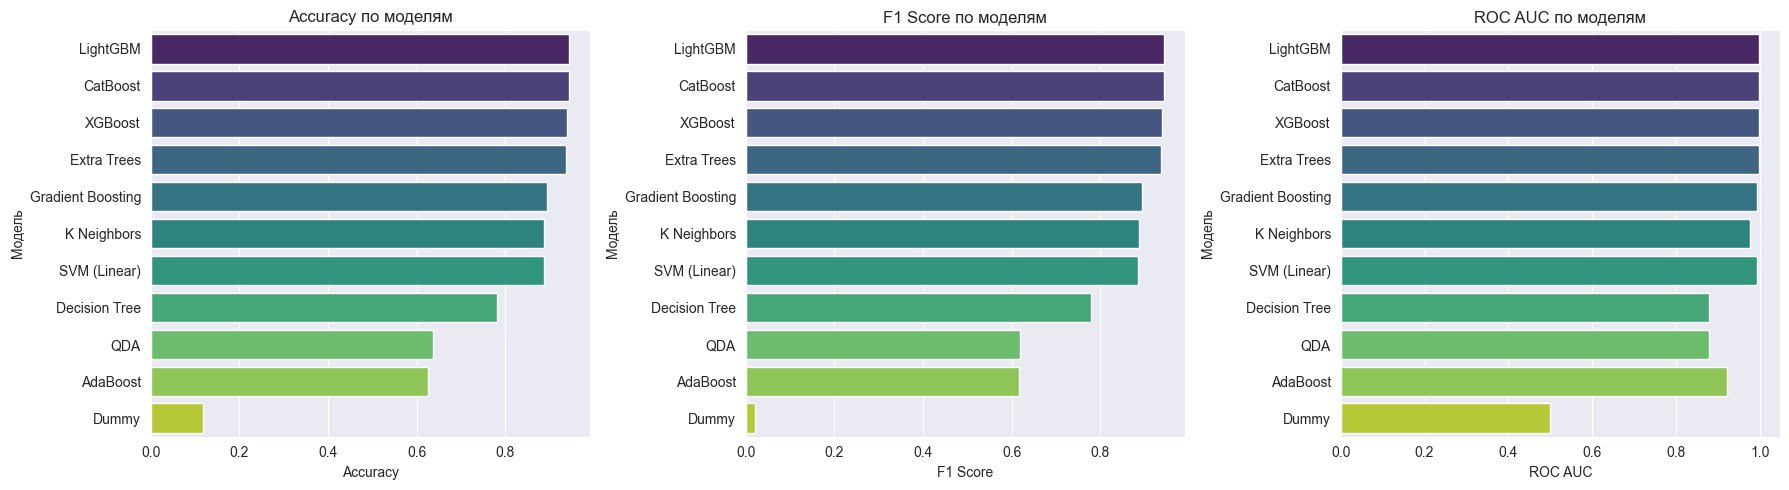

In [16]:
results = []

for name, model in models.items():
    print(f"Training: {name}")
    if name == "QDA":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    try:
        roc = roc_auc_score(y_test, y_proba, multi_class='ovo', average='macro')
    except:
        roc = np.nan

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1,
        "ROC AUC": roc
    })

df_results = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
display(df_results)

# 6. Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["Accuracy", "F1 Score", "ROC AUC"]

for ax, metric in zip(axes, metrics):
    sns.barplot(data=df_results, x=metric, y="Model", ax=ax, palette="viridis")
    ax.set_title(f"{metric} по моделям")
    ax.set_xlabel(metric)
    ax.set_ylabel("Модель")

plt.tight_layout()
plt.show()

In [17]:
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "random_state": 42
    }
    model = LGBMClassifier(**params)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    return f1_score(y_test, preds, average="macro")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Лучшие параметры:", study.best_params)
print("Лучшее F1:", study.best_value)

# 8. Обучение с лучшими параметрами
best_model = LGBMClassifier(**study.best_params)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

print("Final Accuracy:", accuracy_score(y_test, y_pred_best))
print("Final F1 Score:", f1_score(y_test, y_pred_best, average='macro'))

[I 2025-06-12 22:54:53,186] A new study created in memory with name: no-name-1f808df0-7e32-4635-afb4-2aeca0cc327e


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014061 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 89759
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 560
[LightGBM] [Info] Start training from score -2.301586
[LightGBM] [Info] Start training from score -2.183026
[LightGBM] [Info] Start training from score -2.311626
[LightGBM] [Info] Start training from score -2.271086
[LightGBM] [Info] Start training from score -2.322788
[LightGBM] [Info] Start training from score -2.449926
[LightGBM] [Info] Start training from score -2.288682
[LightGBM] [Info] Start training from score -2.234926
[LightGBM] [Info] Start training from score -2.360214
[LightGBM] [Info] Start training from score -2.324831
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

[I 2025-06-12 22:56:24,356] Trial 0 finished with value: 0.9340403674412942 and parameters: {'learning_rate': 0.03144530572044222, 'n_estimators': 288, 'max_depth': 4}. Best is trial 0 with value: 0.9340403674412942.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029955 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 89759
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 560
[LightGBM] [Info] Start training from score -2.301586
[LightGBM] [Info] Start training from score -2.183026
[LightGBM] [Info] Start training from score -2.311626
[LightGBM] [Info] Start training from score -2.271086
[LightGBM] [Info] Start training from score -2.322788
[LightGBM] [Info] Start training from score -2.449926
[LightGBM] [Info] Start training from score -2.288682
[LightGBM] [Info] Start training from score -2.234926
[LightGBM] [Info] Start training from score -2.360214
[LightGBM] [Info] Start training from score -2.324831
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

[I 2025-06-12 22:56:34,613] Trial 1 finished with value: 0.9421306643093855 and parameters: {'learning_rate': 0.279475678880629, 'n_estimators': 228, 'max_depth': 8}. Best is trial 1 with value: 0.9421306643093855.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 89759
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 560
[LightGBM] [Info] Start training from score -2.301586
[LightGBM] [Info] Start training from score -2.183026
[LightGBM] [Info] Start training from score -2.311626
[LightGBM] [Info] Start training from score -2.271086
[LightGBM] [Info] Start training from score

[I 2025-06-12 22:59:37,371] Trial 18 finished with value: 0.9507486756935217 and parameters: {'learning_rate': 0.1684746410779096, 'n_estimators': 228, 'max_depth': 4}. Best is trial 12 with value: 0.9510650377579666.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019785 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 89759
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 560
[LightGBM] [Info] Start training from score -2.301586
[LightGBM] [Info] Start training from score -2.183026
[LightGBM] [Info] Start training from score -2.311626
[LightGBM] [Info] Start training from score -2.271086
[LightGBM] [Info] Start training from score -2.322788
[LightGBM] [Info] Start training from score -2.449926
[LightGBM] [Info] Start training from score -2.288682
[LightGBM] [Info] Start training from score -2.234926
[LightGBM] [Info] Start training from score -2.360214
[LightGBM] [Info] Start training from score -2.324831
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

[I 2025-06-12 22:59:50,729] Trial 19 finished with value: 0.9447153016725365 and parameters: {'learning_rate': 0.1620708719586586, 'n_estimators': 222, 'max_depth': 8}. Best is trial 12 with value: 0.9510650377579666.


Лучшие параметры: {'learning_rate': 0.2118862007740954, 'n_estimators': 259, 'max_depth': 5}
Лучшее F1: 0.9510650377579666
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019741 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 89759
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 560
[LightGBM] [Info] Start training from score -2.301586
[LightGBM] [Info] Start training from score -2.183026
[LightGBM] [Info] Start training from score -2.311626
[LightGBM] [Info] Start training from score -2.271086
[LightGBM] [Info] Start training from score -2.322788
[LightGBM] [Info] Start training from score -2.449926
[LightGBM] [Info] Start training from score -2.288682
[LightGBM] [Info] Start training from score -2.234926
[LightGBM] [Info] Start training from score -2.360214
[LightGBM] [Info] Start training from score -2.324831
[LightGBM] [Warning] No further splits with po

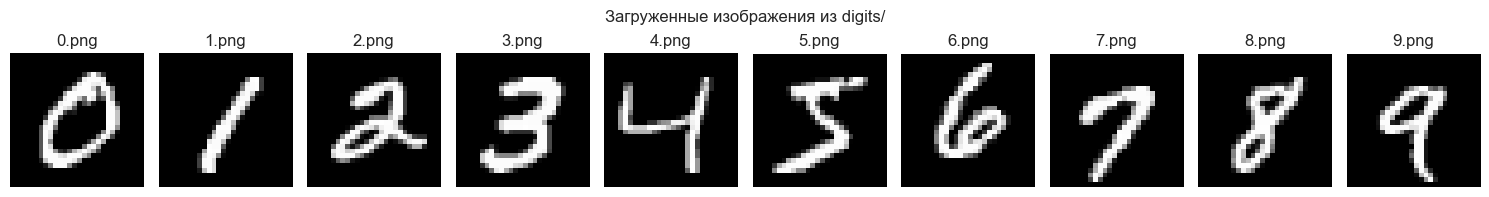

Предсказания для изображений из папки digits:
0.png -> Предсказано: 0
1.png -> Предсказано: 1
2.png -> Предсказано: 2
3.png -> Предсказано: 3
4.png -> Предсказано: 4
5.png -> Предсказано: 5
6.png -> Предсказано: 6
7.png -> Предсказано: 7
8.png -> Предсказано: 8
9.png -> Предсказано: 9


In [21]:
import os
from PIL import Image
import matplotlib.pyplot as plt

for i in range(10):
    sample = X_train_full[y_train_full == i][0]
    img = Image.fromarray(sample)
    img.save(f'digits/{i}.png')


digit_dir = "digits"
image_filenames = sorted([f for f in os.listdir(digit_dir) if f.endswith(".png")], key=lambda x: int(x.split(".")[0]))

X_external = []
fig, axes = plt.subplots(1, 10, figsize=(15, 2))

for i, filename in enumerate(image_filenames):
    img_path = os.path.join(digit_dir, filename)
    img = Image.open(img_path).convert("L").resize((28, 28))

    # Преобразуем в массив
    img_array = np.array(img).astype(np.float32)

    # (если фон белый, а цифра черная — инвертируем)
    if img_array.mean() > 127:
        img_array = 255 - img_array

    # Flatten до 1D вектора
    img_flat = img_array.reshape(1, -1)
    X_external.append(img_flat)

    # Визуализация
    axes[i].imshow(img_array, cmap="gray")
    axes[i].set_title(filename)
    axes[i].axis("off")

plt.suptitle("Загруженные изображения из digits/")
plt.tight_layout()
plt.show()

# Объединяем и масштабируем
X_external = np.vstack(X_external)
X_external_scaled = scaler.transform(X_external)

# Предсказания
external_preds = best_model.predict(X_external_scaled)

# Вывод
print("Предсказания для изображений из папки digits:")
for fname, pred in zip(image_filenames, external_preds):
    print(f"{fname} -> Предсказано: {pred}")